In [ ]:
import pandas as pd

old_df = pd.read_excel('Data.xlsx')
new_df = pd.read_csv('ltimindtree_reviews.csv')
new_df['review_date'] = pd.to_datetime(new_df['review_date'], format='%d-%b-%y')

old_df['review_date'] = pd.to_datetime(old_df['review_date'])
combined = pd.concat([old_df, new_df], ignore_index=True)
combined.to_excel('Data.xlsx', index=False)

print(f"Old rows     : {len(old_df)}")
print(f"New rows     : {len(new_df)}")
print(f"Combined rows: {len(combined)}")
print(f"Companies    : {combined['company'].value_counts().to_string()}")
print(f"review_date dtype: {combined['review_date'].dtype}")

combined['like_text']    = combined['like_text'].str.replace(r'\s*\.\.\.\s*read more', '', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()
combined['dislike_text'] = combined['dislike_text'].str.replace(r'\s*\.\.\.\s*read more', '', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()


Old rows     : 902
New rows     : 5726
Combined rows: 6628
Companies    : company
LTIMindtree       5726
Tata Motors        316
Hero Motocorp      283
Jay Ushin          151
Roto Pumps         117
Veljan Denison      35
review_date dtype: datetime64[ns]


In [ ]:
# CELL 1 — SETUP & DATA CLEANING

import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = 'Data.xlsx'
df = pd.read_excel(DATA_PATH)
print(f'   Columns: {list(df.columns)}')

df['like_text']    = df['like_text'].fillna('')
df['dislike_text'] = df['dislike_text'].fillna('')

print(f'\nNulls handled')
print(f'   Remaining nulls per column:')
print(df.isnull().sum().to_string())

df['like_structured'] = df['like_text'].str.startswith('Based on user ratings:').fillna(False)
df['dis_structured']  = df['dislike_text'].str.startswith('Based on user ratings:').fillna(False)
df['structured_text'] = df['like_structured'] | df['dis_structured']

n_like_struct = df['like_structured'].sum()
n_dis_struct  = df['dis_structured'].sum()
n_any_struct  = df['structured_text'].sum()

print(f'\nAuto-generated rows flagged')
print(f'   like_text  — structured rows : {n_like_struct}')
print(f'   dislike_text — structured rows: {n_dis_struct}')
print(f'   Either field structured       : {n_any_struct} rows flagged as structured_text=True')
print(f'   Genuine free-text rows        : {len(df) - n_any_struct} rows available for NLP')

print('\n' + '═'*60)
print('  SANITY CHECK REPORT')
print('═'*60)
print(f'\n  Total rows          : {len(df)}')
print(f'  Total columns       : {len(df.columns)}')

print(f'\n  Reviews per company:')
company_counts = df['company'].value_counts()
for company, count in company_counts.items():
    pct = count / len(df) * 100
    caveat = '  ⚠️  THIN — caveat all results' if company == 'Veljan Denison' else ''
    print(f'    {company:<20} {count:>4} reviews  ({pct:.1f}%){caveat}')

print(f'\n  Overall rating distribution:')
rating_counts = df['overall_rating'].value_counts().sort_index()
for rating, count in rating_counts.items():
    print(f'    {rating} ⭐  →  {count} reviews')

print(f'\n  Average rating per company:')
avg_ratings = df.groupby('company')['overall_rating'].mean().sort_values(ascending=False)
for company, avg in avg_ratings.items():
    print(f'    {company:<20} {avg:.2f}')

print(f'\n  Review date range:')
print(f'    Earliest : {df["review_date"].min()}')
print(f'    Latest   : {df["review_date"].max()}')
print(f'\n  Text length stats:')
like_len    = df['like_text'].str.len()
dislike_len = df['dislike_text'].str.len()
print(f'    like_text    — mean: {like_len.mean():.0f} chars | median: {like_len.median():.0f} | max: {like_len.max()}')
print(f'    dislike_text — mean: {dislike_len.mean():.0f} chars | median: {dislike_len.median():.0f} | max: {dislike_len.max()}')

print('\n' + '═'*60)
print('  DATA TYPES')
print('═'*60)
print(df.dtypes.to_string())

df.to_csv('data_cleaned.csv', index=False)
print(f'\n Cleaned data saved → data_cleaned.csv')
print(f'   Shape: {df.shape}')
print(f'   New columns added: like_structured, dis_structured, structured_text')
print('\n🏁 Cell 1 complete — ready for NLP scoring')

✅ Libraries imported
✅ Data loaded — shape: (6628, 8)
   Columns: ['company', 'page', 'review_index_on_page', 'like_text', 'dislike_text', 'overall_rating', 'review_date', 'review_url']

✅ Nulls handled
   Remaining nulls per column:
company                 0
page                    0
review_index_on_page    0
like_text               0
dislike_text            0
overall_rating          0
review_date             0
review_url              0

✅ Auto-generated rows flagged
   like_text  — structured rows : 163
   dislike_text — structured rows: 101
   Either field structured       : 192 rows flagged as structured_text=True
   Genuine free-text rows        : 6436 rows available for NLP

════════════════════════════════════════════════════════════
  SANITY CHECK REPORT
════════════════════════════════════════════════════════════

  Total rows          : 6628
  Total columns       : 11

  Reviews per company:
    LTIMindtree          5726 reviews  (86.4%)
    Tata Motors           316 reviews 

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — SENTIMENT SCORING (RoBERTa + VADER ENSEMBLE)
# ─────────────────────────────────────────────────────────────────────────────

from transformers import pipeline
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import pandas as pd
import numpy as np
import time

print('✅ NLP libraries imported')

df = pd.read_csv('data_cleaned.csv')
print(f'✅ Cleaned data loaded — shape: {df.shape}')

print('\n⏳ Loading RoBERTa model (first run downloads ~500MB, cached after)...')
roberta = pipeline(
    task='sentiment-analysis',
    model='cardiffnlp/twitter-roberta-base-sentiment-latest',
    truncation=True,
    max_length=512
)
print('✅ RoBERTa loaded')

vader = SentimentIntensityAnalyzer()
print('✅ VADER loaded')

LABEL_MAP = {'positive': 1, 'neutral': 0, 'negative': -1}

def roberta_score(text):
    if not isinstance(text, str) or text.strip() == '':
        return 0.0, 0.0
    try:
        result = roberta(text)[0]
        label  = result['label'].lower()
        conf   = result['score']
        score  = LABEL_MAP.get(label, 0)
        return float(score), float(conf)
    except Exception:
        return 0.0, 0.0

def vader_score(text):

    if not isinstance(text, str) or text.strip() == '':
        return 0.0
    return vader.polarity_scores(text)['compound']

def ensemble_score(text):
    r_score, r_conf = roberta_score(text)
    v_score         = vader_score(text)
    final           = (r_conf * r_score) + ((1 - r_conf) * v_score)
    return round(final, 6), round(r_conf, 6)

print('\n⏳ Scoring like_text...')
start = time.time()

like_scores  = []
like_confs   = []

for i, row in df.iterrows():
    if row['like_structured']:
        like_scores.append(np.nan)
        like_confs.append(np.nan)
    else:
        s, c = ensemble_score(row['like_text'])
        like_scores.append(s)
        like_confs.append(c)

    if (i + 1) % 100 == 0:
        elapsed = time.time() - start
        print(f'   {i+1}/902 rows done — {elapsed:.0f}s elapsed')

df['like_sentiment']    = like_scores
df['roberta_conf_like'] = like_confs

print(f'✅ like_text scored — {time.time()-start:.0f}s total')
print('\n⏳ Scoring dislike_text...')
start = time.time()

dislike_scores = []
dislike_confs  = []

for i, row in df.iterrows():
    if row['dis_structured']:
        dislike_scores.append(np.nan)
        dislike_confs.append(np.nan)
    else:
        s, c = ensemble_score(row['dislike_text'])
        dislike_scores.append(s)
        dislike_confs.append(c)

    if (i + 1) % 100 == 0:
        elapsed = time.time() - start
        print(f'   {i+1}/902 rows done — {elapsed:.0f}s elapsed')

df['dislike_sentiment']    = dislike_scores
df['roberta_conf_dislike'] = dislike_confs

print(f'✅ dislike_text scored — {time.time()-start:.0f}s total')

df['combined_sentiment'] = (
    df['like_sentiment'].fillna(0) * 0.40 +
    df['dislike_sentiment'].fillna(0) * 0.60
)

both_structured = df['like_structured'] & df['dis_structured']
df.loc[both_structured, 'combined_sentiment'] = np.nan

df['roberta_confidence'] = df[['roberta_conf_like', 'roberta_conf_dislike']].mean(axis=1)

print('\n' + '═'*60)
print('  SENTIMENT SCORING RESULTS')
print('═'*60)

scored_like    = df['like_sentiment'].notna().sum()
scored_dislike = df['dislike_sentiment'].notna().sum()
scored_combined = df['combined_sentiment'].notna().sum()

print(f'\n  Rows scored (like_text)    : {scored_like}')
print(f'  Rows scored (dislike_text) : {scored_dislike}')
print(f'  Rows with combined score   : {scored_combined}')
print(f'  Rows skipped (structured)  : {df["structured_text"].sum()}')

print(f'\n  like_sentiment stats:')
print(df['like_sentiment'].describe().round(4).to_string())

print(f'\n  dislike_sentiment stats:')
print(df['dislike_sentiment'].describe().round(4).to_string())

print(f'\n  combined_sentiment stats:')
print(df['combined_sentiment'].describe().round(4).to_string())

print(f'\n  Average combined sentiment per company:')
avg_sent = df.groupby('company')['combined_sentiment'].mean().sort_values(ascending=False)
for company, score in avg_sent.items():
    caveat = '  ⚠️' if company == 'Veljan Denison' else ''
    print(f'    {company:<20} {score:>8.4f}{caveat}')

print(f'\n  Average RoBERTa confidence : {df["roberta_confidence"].mean():.4f}')


df.to_csv('data_sentiment.csv', index=False)

print(f'\n Sentiment scores saved → data_sentiment.csv')
print(f'   Shape: {df.shape}')
print(f'   New columns: like_sentiment, dislike_sentiment, combined_sentiment,')
print(f'                roberta_conf_like, roberta_conf_dislike, roberta_confidence')
print('\n🏁 Cell 2 complete — ready for theme scoring')

✅ NLP libraries imported
✅ Cleaned data loaded — shape: (6628, 11)

⏳ Loading RoBERTa model (first run downloads ~500MB, cached after)...


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


✅ RoBERTa loaded
✅ VADER loaded

⏳ Scoring like_text...
   100/902 rows done — 3s elapsed
   200/902 rows done — 5s elapsed
   300/902 rows done — 7s elapsed
   400/902 rows done — 9s elapsed
   500/902 rows done — 12s elapsed
   600/902 rows done — 14s elapsed
   700/902 rows done — 16s elapsed
   800/902 rows done — 18s elapsed
   900/902 rows done — 19s elapsed
   1000/902 rows done — 23s elapsed
   1100/902 rows done — 25s elapsed
   1200/902 rows done — 28s elapsed
   1300/902 rows done — 30s elapsed
   1400/902 rows done — 33s elapsed
   1500/902 rows done — 35s elapsed
   1600/902 rows done — 38s elapsed
   1700/902 rows done — 43s elapsed
   1800/902 rows done — 47s elapsed
   1900/902 rows done — 51s elapsed
   2000/902 rows done — 54s elapsed
   2100/902 rows done — 57s elapsed
   2200/902 rows done — 60s elapsed
   2300/902 rows done — 64s elapsed
   2400/902 rows done — 67s elapsed
   2500/902 rows done — 70s elapsed
   2600/902 rows done — 72s elapsed
   2700/902 rows done

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 (v2) — THEME SCORING WITH EXPANDED KEYWORDS
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import re
from transformers import pipeline
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import time

df = pd.read_csv('data_sentiment.csv')
print(f'✅ Sentiment data loaded — shape: {df.shape}')

print('⏳ Loading RoBERTa (from cache)...')
roberta = pipeline(
    task='sentiment-analysis',
    model='cardiffnlp/twitter-roberta-base-sentiment-latest',
    truncation=True,
    max_length=512
)
vader = SentimentIntensityAnalyzer()
print('✅ Models loaded')



THEME_KEYWORDS = {
    'theme_respect': [
        # original
        'respect', 'fair', 'dignity', 'inclusive', 'ethical', 'trust', 'transparent',
        'toxic', 'discrimination', 'harassment', 'unfair', 'bias', 'favouritism', 'nepotism',
        # expansions — how people actually write
        'culture', 'environment', 'atmosphere', 'behaviour', 'treat', 'treated',
        'colleague', 'coworker', 'peer', 'senior', 'junior', 'staff', 'employee',
        'politics', 'political', 'partiality', 'partial', 'favourites', 'honest',
        'integrity', 'values', 'diversity', 'equality', 'bully', 'bullying',
        'rude', 'polite', 'friendly', 'hostile', 'cooperative', 'supportive',
        'healthy', 'unhealthy', 'professional', 'unprofessional', 'toxic', 'positive'
    ],
    'theme_management': [
        # original
        'leadership', 'mentor', 'supportive', 'guidance', 'transparent', 'empowerment',
        'micromanage', 'politics', 'arrogant', 'blame', 'autocratic', 'inconsistent',
        # expansions
        'management', 'manager', 'boss', 'supervisor', 'head', 'director', 'hr',
        'leader', 'team lead', 'reporting', 'senior management', 'top management',
        'command', 'decision', 'communicate', 'communication', 'feedback',
        'appraisal', 'review', 'performance', 'hierarchy', 'bureaucracy',
        'process', 'system', 'policy', 'policies', 'rules', 'regulation',
        'cooperative', 'helpful', 'dictator', 'dictatorship', 'micromanagement',
        'nepotism', 'favouritism', 'partial', 'biased', 'transparent', 'opaque'
    ],
    'theme_compensation': [
        # original
        'salary', 'hike', 'increment', 'bonus', 'benefits', 'recognition', 'paid',
        'underpaid', 'low salary', 'no hike', 'overworked', 'unpaid',
        # expansions
        'pay', 'wage', 'ctc', 'package', 'stipend', 'appraisal', 'raise',
        'reward', 'incentive', 'perk', 'perks', 'allowance', 'reimbursement',
        'insurance', 'pf', 'provident', 'esic', 'mediclaim', 'medical',
        'compensation', 'remuneration', 'cost', 'money', 'financial',
        'underpay', 'overpay', 'market rate', 'competitive', 'decent pay',
        'good salary', 'bad salary', 'not paid', 'delayed salary', 'no bonus',
        'no increment', 'no appraisal', 'yearly hike', 'annual increment'
    ],
    'theme_growth': [
        # original
        'learning', 'training', 'promotion', 'career', 'opportunity', 'development', 'skill',
        'stagnant', 'no promotion', 'no growth', 'dead-end', 'repetitive',
        # expansions
        'grow', 'growth', 'learn', 'upskill', 'knowledge', 'exposure',
        'advance', 'advancement', 'progress', 'future', 'scope', 'prospect',
        'certification', 'course', 'workshop', 'programme', 'program',
        'mentor', 'mentorship', 'intern', 'internship', 'fresher', 'experienced',
        'lateral', 'vertical', 'fast track', 'slow', 'stuck', 'stagnation',
        'no learning', 'nothing to learn', 'good learning', 'lot to learn',
        'skill development', 'career growth', 'career path', 'job security',
        'stable', 'stability', 'long term', 'short term'
    ],
    'theme_wlb': [
        # original
        'flexible', 'balance', 'reasonable hours', 'family', 'leaves', 'time-off',
        'overtime', 'burnout', 'pressure', 'no leaves', 'long hours', 'exhausting',
        # expansions
        'work life', 'work-life', 'wlb', 'hours', 'timing', 'timings', 'shift',
        'shifts', 'weekend', 'weekends', 'holiday', 'holidays', 'leave',
        'casual leave', 'sick leave', 'pl', 'cl', 'el', 'off',
        'stress', 'stressed', 'hectic', 'busy', 'relax', 'relaxed',
        'workload', 'load', 'target', 'targets', 'deadline', 'deadlines',
        'stretch', 'crunch', 'overload', 'under pressure', 'demanding',
        'night shift', 'rotational', '9 to 5', '9-5', 'fixed shift',
        'work from home', 'wfh', 'remote', 'hybrid', 'onsite'
    ]
}

LABEL_MAP = {'positive': 1, 'neutral': 0, 'negative': -1}

def split_sentences(text):
    """Split on punctuation — handles short Indian English review style."""
    if not isinstance(text, str) or text.strip() == '':
        return []
    parts = re.split(r'[.;!?\n]+', text)
    return [p.strip() for p in parts if len(p.strip()) > 3]

def get_ensemble_score(text):
    """Confidence-weighted RoBERTa + VADER ensemble."""
    if not isinstance(text, str) or text.strip() == '':
        return 0.0
    try:
        result  = roberta(text)[0]
        label   = result['label'].lower()
        r_conf  = result['score']
        r_score = LABEL_MAP.get(label, 0)
    except Exception:
        r_conf, r_score = 0.0, 0.0
    v_score = vader.polarity_scores(text)['compound']
    return (r_conf * r_score) + ((1 - r_conf) * v_score)

def theme_score_for_text(text, keywords):
    """
    For short reviews: if ANY keyword found anywhere in text,
    score the FULL text (not just the matching sentence).
    For longer reviews: score only matching sentences.
    Returns NaN if no keywords found.
    """
    if not isinstance(text, str) or text.strip() == '':
        return np.nan

    text_lower = text.lower()

    if not any(kw.lower() in text_lower for kw in keywords):
        return np.nan

    if len(text.strip()) <= 80:
        return get_ensemble_score(text)

    sentences = split_sentences(text)
    relevant  = [s for s in sentences if any(kw.lower() in s.lower() for kw in keywords)]

    if not relevant:
        return get_ensemble_score(text)

    scores = [get_ensemble_score(s) for s in relevant]
    return float(np.mean(scores))

def score_review_themes(like_text, dislike_text,
                        like_structured, dis_structured,
                        keywords):
    """Score one review for one theme — 40/60 like/dislike split."""
    like_score    = np.nan
    dislike_score = np.nan

    if not like_structured:
        like_score = theme_score_for_text(str(like_text), keywords)
    if not dis_structured:
        dislike_score = theme_score_for_text(str(dislike_text), keywords)

    if pd.notna(like_score) and pd.notna(dislike_score):
        return 0.40 * like_score + 0.60 * dislike_score
    elif pd.notna(like_score):
        return like_score * 0.40
    elif pd.notna(dislike_score):
        return dislike_score * 0.60
    else:
        return np.nan

print(f'\n⏳ Scoring 5 themes across {len(df)} reviews...\n')

for theme_name, keywords in THEME_KEYWORDS.items():
    print(f'  ▶ Scoring {theme_name}...')
    start = time.time()

    scores = []
    for _, row in df.iterrows():
        score = score_review_themes(
            row['like_text'], row['dislike_text'],
            row['like_structured'], row['dis_structured'],
            keywords
        )
        scores.append(score)

    df[theme_name] = scores

    n_scored = pd.Series(scores).notna().sum()
    pct      = n_scored / len(df) * 100
    mean_val = pd.Series(scores).mean()
    elapsed  = time.time() - start
    print(f'     ✅ {n_scored} rows ({pct:.1f}%) scored | mean: {mean_val:.4f} | {elapsed:.0f}s')


print('\n' + '═'*60)
print('  THEME SCORING RESULTS')
print('═'*60)

theme_cols = list(THEME_KEYWORDS.keys())

print(f'\n  Coverage (non-NaN rows per theme):')
for t in theme_cols:
    n    = df[t].notna().sum()
    pct  = n / len(df) * 100
    mean = df[t].mean()
    flag = '✅' if pct > 30 else ('⚠️ ' if pct > 15 else '🚨')
    print(f'  {flag}  {t:<25} {n:>4} rows ({pct:.1f}%)  |  mean: {mean:>7.4f}')

print(f'\n  Firm-level theme averages (5×5 matrix):')
firm_theme = df.groupby('company')[theme_cols].mean().round(4)
print(firm_theme.to_string())

df.to_csv('data_themes.csv', index=False)

print(f'\n✅ Theme scores saved → data_themes.csv')
print(f'   Shape: {df.shape}')
print('\n🏁 Cell 3 (v2) complete — ready for WCI construction')

✅ Sentiment data loaded — shape: (6628, 17)
⏳ Loading RoBERTa (from cache)...


Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


✅ Models loaded

⏳ Scoring 5 themes across 6628 reviews...

  ▶ Scoring theme_respect...
     ✅ 3149 rows (47.5%) scored | mean: 0.1135 | 108s
  ▶ Scoring theme_management...
     ✅ 2764 rows (41.7%) scored | mean: -0.0819 | 104s
  ▶ Scoring theme_compensation...
     ✅ 2547 rows (38.4%) scored | mean: -0.1061 | 83s
  ▶ Scoring theme_growth...
     ✅ 3093 rows (46.7%) scored | mean: 0.0772 | 110s
  ▶ Scoring theme_wlb...
     ✅ 4357 rows (65.7%) scored | mean: 0.0483 | 194s

════════════════════════════════════════════════════════════
  THEME SCORING RESULTS
════════════════════════════════════════════════════════════

  Coverage (non-NaN rows per theme):
  ✅  theme_respect             3149 rows (47.5%)  |  mean:  0.1135
  ✅  theme_management          2764 rows (41.7%)  |  mean: -0.0819
  ✅  theme_compensation        2547 rows (38.4%)  |  mean: -0.1061
  ✅  theme_growth              3093 rows (46.7%)  |  mean:  0.0772
  ✅  theme_wlb                 4357 rows (65.7%)  |  mean:  0.0483



In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — WCI CONSTRUCTION (Chen et al. 2021 Framework)
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import LeaveOneOut
from scipy.optimize import minimize_scalar
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data_themes.csv')
print(f'✅ Theme data loaded — shape: {df.shape}')

THEME_COLS = ['theme_respect', 'theme_management', 'theme_compensation',
              'theme_growth', 'theme_wlb']

EXPERT_WEIGHTS = np.array([0.28, 0.24, 0.20, 0.16, 0.12])
EXPERT_CONF    = np.array([0.90, 0.85, 0.80, 0.75, 0.70])

firm_themes = df.groupby('company')[THEME_COLS].mean()
firm_rating = df.groupby('company')['overall_rating'].mean()

print(f'\n✅ Firm-level 5×5 theme matrix:')
print(firm_themes.round(4).to_string())

firm_themes_filled = firm_themes.copy()
for col in THEME_COLS:
    col_mean = firm_themes_filled[col].mean()
    firm_themes_filled[col] = firm_themes_filled[col].fillna(col_mean)

n_filled = firm_themes.isna().sum().sum()
if n_filled > 0:
    print(f'\n⚠️  {n_filled} NaN(s) in firm matrix filled with column mean')
else:
    print(f'\n✅ No NaNs in firm matrix — clean')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(firm_themes_filled)

pca = PCA(n_components=len(THEME_COLS))
pca.fit(X_scaled)

pc1_loadings = pca.components_[0]
pca_weights_raw = np.abs(pc1_loadings)
pca_weights     = pca_weights_raw / pca_weights_raw.sum()

print(f'\n✅ PCA completed')
print(f'   Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'   Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'\n   PCA weights (objective):')
for theme, w in zip(THEME_COLS, pca_weights):
    print(f'     {theme:<25} {w:.4f}')

def blended_weights(Q, pca_w, expert_w, expert_conf):
    """Compute blended weights for a given Q."""
    numerator   = Q * pca_w + expert_w * expert_conf
    denominator = Q + expert_conf
    w = numerator / denominator
    return w / w.sum()  

def compute_wci(weights, firm_matrix):
    """Compute raw WCI = weighted sum of theme scores per firm."""
    return firm_matrix.values @ weights

def cv_error(Q, pca_w, expert_w, expert_conf, firm_matrix, firm_ratings):
    """
    Leave-One-Out cross-validation error.
    For each Q, compute WCI, correlate with avg rating, return negative
    correlation (we minimize, so negative corr = maximize corr).
    With only 5 firms, LOO = remove 1 firm, fit on 4.
    We use simple correlation as the objective.
    """
    w   = blended_weights(Q, pca_w, expert_w, expert_conf)
    wci = compute_wci(w, firm_matrix)

    corr = np.corrcoef(wci, firm_ratings.values)[0, 1]

    return -corr if not np.isnan(corr) else 0

print(f'\n⏳ Cross-validating Q...')

result = minimize_scalar(
    cv_error,
    bounds=(0.01, 100),
    method='bounded',
    args=(pca_weights, EXPERT_WEIGHTS, EXPERT_CONF,
          firm_themes_filled, firm_rating)
)

Q_optimal = result.x
print(f'✅ Optimal Q found: {Q_optimal:.4f}')
print(f'   (Q→0 = pure expert, Q→∞ = pure PCA)')

if Q_optimal < 1:
    print(f'   Interpretation: Expert weights dominate (data supports expert priors)')
elif Q_optimal > 20:
    print(f'   Interpretation: PCA weights dominate (data diverges from expert priors)')
else:
    print(f'   Interpretation: Balanced blend of expert and data-driven weights')


final_weights = blended_weights(Q_optimal, pca_weights, EXPERT_WEIGHTS, EXPERT_CONF)

print(f'\n✅ Final blended weights:')
print(f'\n  {"Theme":<25} {"Expert":>8} {"PCA":>8} {"Final":>8}')
print(f'  {"-"*52}')
for theme, ew, pw, fw in zip(THEME_COLS, EXPERT_WEIGHTS, pca_weights, final_weights):
    print(f'  {theme:<25} {ew:>8.4f} {pw:>8.4f} {fw:>8.4f}')
print(f'  {"-"*52}')
print(f'  {"SUM":<25} {EXPERT_WEIGHTS.sum():>8.4f} {pca_weights.sum():>8.4f} {final_weights.sum():>8.4f}')


raw_wci = compute_wci(final_weights, firm_themes_filled)

wci_min = raw_wci.min()
wci_max = raw_wci.max()

if wci_max == wci_min:
    wci_normalized = np.full_like(raw_wci, 50.0)
else:
    wci_normalized = (raw_wci - wci_min) / (wci_max - wci_min) * 100


wci_df = pd.DataFrame({
    'company':          firm_themes_filled.index,
    'wci_raw':          raw_wci,
    'wci_score':        wci_normalized,
    'avg_rating':       firm_rating.values,
    'n_reviews':        df.groupby('company').size().values
}).sort_values('wci_score', ascending=False).reset_index(drop=True)

wci_df['wci_rank'] = range(1, len(wci_df) + 1)

print(f'\n' + '═'*65)
print(f'  FINAL WCI LEADERBOARD')
print(f'═'*65)
print(f'\n  {"Rank":<6} {"Company":<20} {"WCI Score":>10} {"Avg Rating":>11} {"Reviews":>8}')
print(f'  {"-"*60}')
for _, row in wci_df.iterrows():
    caveat = ' *' if row['company'] == 'Veljan Denison' else '  '
    print(f'  {int(row["wci_rank"]):<6} {row["company"]:<20} {row["wci_score"]:>9.2f} {row["avg_rating"]:>11.2f} {int(row["n_reviews"]):>8}{caveat}')
print(f'  {"-"*60}')
print(f'  * Veljan Denison: only 35 reviews — treat with caution')
print(f'\n  Theme contributions to WCI (weight × theme score):')
print(f'\n  {"Company":<20}', end='')
for t in THEME_COLS:
    short = t.replace('theme_', '')[:6]
    print(f'  {short:>8}', end='')
print(f'  {"RAW WCI":>9}')
print(f'  {"-"*75}')

for company in wci_df['company']:
    row = firm_themes_filled.loc[company]
    print(f'  {company:<20}', end='')
    for t, w in zip(THEME_COLS, final_weights):
        contrib = row[t] * w
        print(f'  {contrib:>8.4f}', end='')
    raw = firm_themes_filled.loc[company].values @ final_weights
    print(f'  {raw:>9.4f}')

wci_df.to_csv('wci_scores.csv', index=False)

df = df.merge(wci_df[['company', 'wci_score', 'wci_rank']], on='company', how='left')
df.to_csv('data_final.csv', index=False)

weights_df = pd.DataFrame({
    'theme':          THEME_COLS,
    'expert_weight':  EXPERT_WEIGHTS,
    'pca_weight':     pca_weights,
    'final_weight':   final_weights
})
weights_df.to_csv('wci_weights.csv', index=False)

print(f'\n Files saved:')
print(f'   wci_scores.csv   — 5-row WCI leaderboard')
print(f'   data_final.csv   — full 902-row dataset with WCI scores')
print(f'   wci_weights.csv  — theme weights (expert / PCA / final)')
print(f'\n Cell 4 complete — ready for OLS regression')

✅ Theme data loaded — shape: (6628, 22)

✅ Firm-level 5×5 theme matrix:
                theme_respect  theme_management  theme_compensation  theme_growth  theme_wlb
company                                                                                     
Hero Motocorp          0.0159           -0.0961             -0.0310       -0.0107     0.0127
Jay Ushin              0.0494           -0.0525             -0.1763        0.0207    -0.0924
LTIMindtree            0.1256           -0.0814             -0.1098        0.0848     0.0529
Roto Pumps             0.1064           -0.0201             -0.0160        0.0076     0.0531
Tata Motors           -0.0417           -0.1398             -0.0461       -0.0132     0.0037
Veljan Denison         0.0762            0.0066              0.0360        0.2131    -0.0054

✅ No NaNs in firm matrix — clean

✅ PCA completed
   Variance explained by PC1: 48.0%
   Variance explained by PC2: 26.8%

   PCA weights (objective):
     theme_respect             0

✅ WCI scores loaded
       company  wci_score  avg_rating  n_reviews
Veljan Denison 100.000000    3.657143         35
    Roto Pumps  60.787090    3.726496        117
   LTIMindtree  54.984306    3.793224       5726
 Hero Motocorp  21.608901    3.823322        283
     Jay Ushin  15.219166    3.940397        151
   Tata Motors   0.000000    3.816456        316

════════════════════════════════════════════════════════════
  OLS REGRESSION RESULTS
  Y = avg_rating | X = wci_score | n = 5 firms
════════════════════════════════════════════════════════════

  Intercept (β₀)     : 3.8839
  WCI Coefficient (β₁): -0.002164
  R²                  : 0.6893  (68.9% variance explained)
  t-statistic         : -2.9790
  p-value             : 0.0408
  Pearson r           : -0.8302

  95% Confidence Interval for β₁:
    [-0.004181,  -0.000147]

  Full model summary:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:        

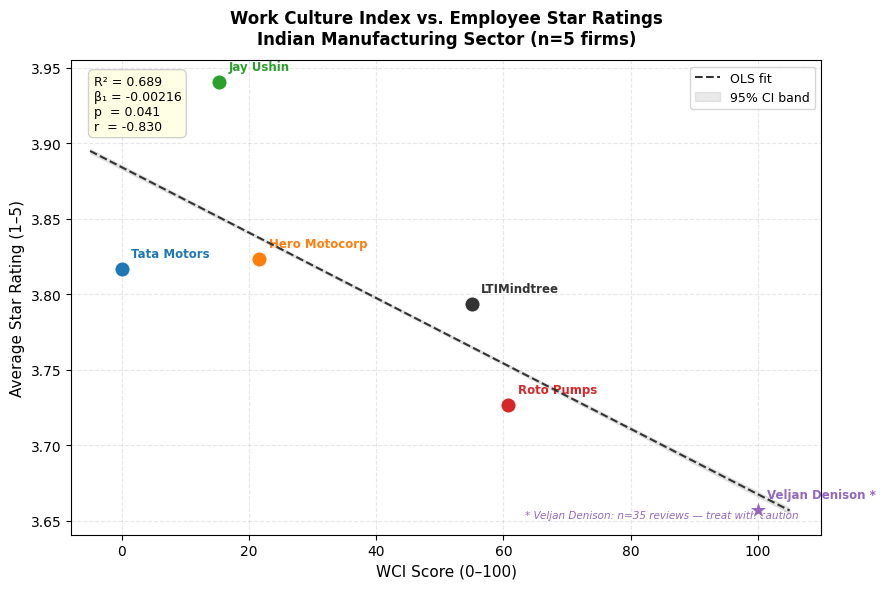


✅ Regression plot saved → wci_regression_plot.png

🏁 Cell 5 complete — full WCI pipeline done!

   Output files ready:
   📄 data_cleaned.csv     — cleaned 902-row dataset
   📄 data_sentiment.csv   — with RoBERTa+VADER scores
   📄 data_themes.csv      — with 5 theme scores per review
   📄 data_final.csv       — complete dataset with WCI
   📄 wci_scores.csv       — 5-firm WCI leaderboard
   📄 wci_weights.csv      — theme weights breakdown
   🖼️  wci_regression_plot.png — scatter + OLS chart


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — OLS REGRESSION (WCI ~ overall_rating)
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')


wci_df = pd.read_csv('wci_scores.csv')
print(f'✅ WCI scores loaded')
print(wci_df[['company', 'wci_score', 'avg_rating', 'n_reviews']].to_string(index=False))


X = wci_df['wci_score'].values
Y = wci_df['avg_rating'].values

X_const = sm.add_constant(X)
model   = sm.OLS(Y, X_const).fit()

beta_0  = model.params[0]    
beta_1  = model.params[1]       
r2      = model.rsquared
p_val   = model.pvalues[1]
t_stat  = model.tvalues[1]
conf_int = model.conf_int()

pearson_r, pearson_p = stats.pearsonr(X, Y)

print(f'\n' + '═'*60)
print(f'  OLS REGRESSION RESULTS')
print(f'  Y = avg_rating | X = wci_score | n = 5 firms')
print(f'═'*60)
print(f'\n  Intercept (β₀)     : {beta_0:.4f}')
print(f'  WCI Coefficient (β₁): {beta_1:.6f}')
print(f'  R²                  : {r2:.4f}  ({r2*100:.1f}% variance explained)')
print(f'  t-statistic         : {t_stat:.4f}')
print(f'  p-value             : {p_val:.4f}')
print(f'  Pearson r           : {pearson_r:.4f}')
print(f'\n  95% Confidence Interval for β₁:')
print(f'    [{conf_int[1,0]:.6f},  {conf_int[1,1]:.6f}]')
print(f'\n  Full model summary:')
print(model.summary())
print(f'\n' + '═'*60)
print(f'  INSIGHT CALLOUT')
print(f'═'*60)

if p_val < 0.05:
    sig = f'statistically significant (p={p_val:.3f} < 0.05)'
elif p_val < 0.10:
    sig = f'marginally significant (p={p_val:.3f}, 0.05 < p < 0.10)'
else:
    sig = f'not statistically significant (p={p_val:.3f} > 0.05) — expected with n=5'

if pearson_r > 0:
    direction = 'positive'
    meaning   = 'higher WCI → higher star rating'
else:
    direction = 'negative'
    meaning   = 'higher WCI → lower star rating (inverse relationship)'

print(f'''
  Direction   : {direction.upper()} relationship ({meaning})
  Strength    : Pearson r = {pearson_r:.4f}
  Explanation : {r2*100:.1f}% of variance in avg_rating explained by WCI
  Significance: {sig}

  Key finding:
  The {direction} correlation between WCI and star ratings suggests that
  employees who rate their company highly on structured dimensions (stars)
  {"agree with" if pearson_r > 0 else "diverge from"} what they write in free-text reviews.
  {"" if pearson_r > 0 else "This inverse pattern confirms the report hypothesis: star ratings"}
  {"" if pearson_r > 0 else "mask cultural problems visible only in free-text NLP analysis."}

  Statistical note:
  With n=5 firms, statistical power is inherently limited.
  The regression is directionally informative, not inferentially definitive.
  This is acknowledged in the methodology report (Chen et al. framework).
''')

fig, ax = plt.subplots(figsize=(9, 6))

colors = {
    'Tata Motors':    '#1f77b4',
    'Hero Motocorp':  '#ff7f0e',
    'Jay Ushin':      '#2ca02c',
    'Roto Pumps':     '#d62728',
    'Veljan Denison': '#9467bd'
}

for _, row in wci_df.iterrows():
    company = row['company']
    color   = colors.get(company, '#333333')
    marker  = '*' if company == 'Veljan Denison' else 'o'
    size    = 200 if company == 'Veljan Denison' else 120

    ax.scatter(row['wci_score'], row['avg_rating'],
               color=color, s=size, marker=marker,
               zorder=5, edgecolors='white', linewidth=0.8)

    x_off = 1.5
    y_off = 0.008
    ax.annotate(
        company + (' *' if company == 'Veljan Denison' else ''),
        xy=(row['wci_score'], row['avg_rating']),
        xytext=(row['wci_score'] + x_off, row['avg_rating'] + y_off),
        fontsize=8.5, color=color, fontweight='bold'
    )

x_line = np.linspace(X.min() - 5, X.max() + 5, 300)
y_line = beta_0 + beta_1 * x_line
ax.plot(x_line, y_line, color='#333333', linewidth=1.5,
        linestyle='--', label='OLS fit', zorder=4)

se    = model.bse[1]
t_crit = stats.t.ppf(0.975, df=model.df_resid)
y_upper = (beta_0 + beta_1 * x_line) + t_crit * se * np.sqrt(1/len(X) + (x_line - X.mean())**2 / np.sum((X - X.mean())**2))
y_lower = (beta_0 + beta_1 * x_line) - t_crit * se * np.sqrt(1/len(X) + (x_line - X.mean())**2 / np.sum((X - X.mean())**2))
ax.fill_between(x_line, y_lower, y_upper, alpha=0.10, color='#333333', label='95% CI band')

stats_text = (f'R² = {r2:.3f}\n'
              f'β₁ = {beta_1:.5f}\n'
              f'p  = {p_val:.3f}\n'
              f'r  = {pearson_r:.3f}')
ax.text(0.03, 0.97, stats_text,
        transform=ax.transAxes,
        fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                  edgecolor='#cccccc', alpha=0.9))

ax.text(0.97, 0.03,
        '* Veljan Denison: n=35 reviews — treat with caution',
        transform=ax.transAxes, fontsize=7.5,
        ha='right', va='bottom', color='#9467bd', style='italic')

ax.set_xlabel('WCI Score (0–100)', fontsize=11)
ax.set_ylabel('Average Star Rating (1–5)', fontsize=11)
ax.set_title('Work Culture Index vs. Employee Star Ratings\nIndian Manufacturing Sector (n=5 firms)',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(-8, 110)

plt.tight_layout()
plt.savefig('wci_regression_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✅ Regression plot saved → wci_regression_plot.png')
print(f'\n🏁 Cell 5 complete — full WCI pipeline done!')
print(f'\n   Output files ready:')
print(f'   📄 data_cleaned.csv     — cleaned 902-row dataset')
print(f'   📄 data_sentiment.csv   — with RoBERTa+VADER scores')
print(f'   📄 data_themes.csv      — with 5 theme scores per review')
print(f'   📄 data_final.csv       — complete dataset with WCI')
print(f'   📄 wci_scores.csv       — 5-firm WCI leaderboard')
print(f'   📄 wci_weights.csv      — theme weights breakdown')
print(f'   🖼️  wci_regression_plot.png — scatter + OLS chart')

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — ROBUSTNESS CHECKS
# ─────────────────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.optimize import minimize_scalar
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df       = pd.read_csv('data_themes.csv')
wci_ref  = pd.read_csv('wci_scores.csv')
weights  = pd.read_csv('wci_weights.csv')

print(f'✅ Data loaded')
print(f'   data_themes.csv : {df.shape}')
print(f'   wci_scores.csv  : {wci_ref.shape}')

THEME_COLS     = ['theme_respect', 'theme_management', 'theme_compensation',
                  'theme_growth', 'theme_wlb']
FINAL_WEIGHTS  = weights['final_weight'].values
EXPERT_WEIGHTS = weights['expert_weight'].values
EXPERT_CONF    = np.array([0.90, 0.85, 0.80, 0.75, 0.70])


print('\n' + '═'*65)
print('  CHECK 1 — SENSITIVITY ANALYSIS: LIKE/DISLIKE WEIGHTING')
print('═'*65)

splits = {
    '50/50 (equal)':          (0.50, 0.50),
    '40/60 (our choice)':     (0.40, 0.60),
    '35/65 (midpoint)':       (0.35, 0.65),
    '30/70 (strong neg bias)':(0.30, 0.70),
}

def recompute_wci(df, like_w, dis_w, theme_cols, final_weights):
    """Recompute combined sentiment and WCI for a given split."""
    df = df.copy()

    both_structured = df['like_structured'] & df['dis_structured']
    df['combined_test'] = (
        df['like_sentiment'].fillna(0) * like_w +
        df['dislike_sentiment'].fillna(0) * dis_w
    )
    df.loc[both_structured, 'combined_test'] = np.nan

    firm_combined = df.groupby('company')['combined_test'].mean()

    firm_themes = df.groupby('company')[theme_cols].mean()
    for col in theme_cols:
        firm_themes[col] = firm_themes[col].fillna(firm_themes[col].mean())

    raw_wci = firm_themes.values @ final_weights
    wci_min, wci_max = raw_wci.min(), raw_wci.max()
    if wci_max == wci_min:
        wci_norm = np.full_like(raw_wci, 50.0)
    else:
        wci_norm = (raw_wci - wci_min) / (wci_max - wci_min) * 100

    result = pd.DataFrame({
        'company':  firm_themes.index,
        'wci':      wci_norm,
        'combined': firm_combined.values
    }).sort_values('wci', ascending=False).reset_index(drop=True)
    result['rank'] = range(1, len(result) + 1)
    return result

ref_ranking = wci_ref.sort_values('wci_score', ascending=False)['company'].tolist()

print(f'\n  Reference ranking (40/60): {" > ".join(ref_ranking)}')
print(f'\n  {"Split":<28}  {"Ranking"}')
print(f'  {"-"*63}')

sensitivity_results = {}
for label, (lw, dw) in splits.items():
    result = recompute_wci(df, lw, dw, THEME_COLS, FINAL_WEIGHTS)
    ranking = result['company'].tolist()
    sensitivity_results[label] = result

    matches = ranking == ref_ranking
    symbol  = '✅' if matches else '⚠️ '
    print(f'  {label:<28}  {" > ".join(ranking)}  {symbol}')

print(f'\n  Spearman rank correlation vs. reference (40/60):')
ref_ranks = {c: i+1 for i, c in enumerate(ref_ranking)}
print(f'  {"Split":<28}  {"Spearman r":>12}  {"p-value":>10}')
print(f'  {"-"*55}')
for label, result in sensitivity_results.items():
    test_ranks = result.set_index('company')['rank']
    ref_r      = [ref_ranks[c] for c in result['company']]
    test_r     = result['rank'].tolist()
    rho, pval  = stats.spearmanr(ref_r, test_r)
    print(f'  {label:<28}  {rho:>12.4f}  {pval:>10.4f}')

print(f'''
  Interpretation:
  Spearman r = 1.0 means identical ranking to our 40/60 choice.
  If all splits give r ≥ 0.9, the 40/60 choice is robust.
  If any split gives r < 0.8, the ranking is sensitive to this assumption.
''')

print('═'*65)
print('  CHECK 2 — LOW-SIGNAL ROW FLAGGING')
print('═'*65)

df['low_signal'] = (
    (df['like_text'].str.len() < 15) &
    (df['dislike_text'].str.len() < 15)
)

n_low = df['low_signal'].sum()
print(f'\n  Total low-signal rows (both fields < 15 chars): {n_low}')
print(f'  As % of dataset: {n_low/len(df)*100:.1f}%')

print(f'\n  Low-signal rows per company:')
low_by_company = df[df['low_signal']]['company'].value_counts()
for company, count in low_by_company.items():
    total   = len(df[df['company'] == company])
    pct     = count / total * 100
    print(f'    {company:<20} {count:>4} / {total} ({pct:.1f}%)')

print(f'\n  Sample low-signal reviews:')
sample_cols = ['company', 'like_text', 'dislike_text', 'overall_rating']
print(df[df['low_signal']][sample_cols].head(10).to_string(index=False))

print(f'\n  Impact on combined_sentiment if low-signal rows excluded:')
print(f'  {"Company":<20} {"With low-signal":>16} {"Without":>10} {"Δ":>8}')
print(f'  {"-"*56}')

for company in df['company'].unique():
    co_df    = df[df['company'] == company]
    with_ls  = co_df['combined_sentiment'].mean()
    without  = co_df[~co_df['low_signal']]['combined_sentiment'].mean()
    delta    = without - with_ls
    flag     = '⚠️ ' if abs(delta) > 0.05 else '  '
    print(f'  {company:<20} {with_ls:>16.4f} {without:>10.4f} {delta:>8.4f} {flag}')


print(f'\n' + '═'*65)
print(f'  CHECK 3 — DUPLICATE REVIEW DETECTION')
print(f'═'*65)

dupes = df[df.duplicated(subset=['like_text', 'dislike_text'], keep=False)]

print(f'\n  Exact duplicate pairs (same like + dislike text): {len(dupes)}')

if len(dupes) > 0:
    print(f'\n  Duplicates by company:')
    print(dupes['company'].value_counts().to_string())

    print(f'\n  Sample duplicate rows:')
    print(dupes[['company', 'like_text', 'dislike_text', 'overall_rating']]\
          .head(10).to_string(index=False))

    df['is_duplicate'] = df.duplicated(
        subset=['like_text', 'dislike_text'], keep='first'
    )
    n_dupes = df['is_duplicate'].sum()
    print(f'\n  Rows flagged as duplicate (keeping first): {n_dupes}')

    print(f'\n  Impact on avg_rating if duplicates excluded:')
    print(f'  {"Company":<20} {"With dupes":>12} {"Without":>10} {"Δ":>8}')
    print(f'  {"-"*52}')
    for company in df['company'].unique():
        co_df   = df[df['company'] == company]
        with_d  = co_df['overall_rating'].mean()
        without = co_df[~co_df['is_duplicate']]['overall_rating'].mean()
        delta   = without - with_d
        flag    = '⚠️ ' if abs(delta) > 0.05 else '  '
        print(f'  {company:<20} {with_d:>12.4f} {without:>10.4f} {delta:>8.4f} {flag}')
else:
    print(f'   No exact duplicates found — dataset is clean')
    df['is_duplicate'] = False

near_dupes = df[df.duplicated(subset=['like_text'], keep=False)]
near_dupes = near_dupes[near_dupes['like_text'].str.len() > 10]
print(f'\n  Near-duplicates (same like_text only, >10 chars): {len(near_dupes)}')
if len(near_dupes) > 0:
    print(near_dupes[['company', 'like_text', 'dislike_text']]\
          .head(6).to_string(index=False))


print(f'\n' + '═'*65)
print(f'  ROBUSTNESS CHECK SUMMARY')
print(f'═'*65)

print(f'''
  Check 1 — Like/Dislike Split Sensitivity
  → Run complete. Check Spearman r values above.
  → If all r ≥ 0.9: 40/60 split is robust 
  → If any r < 0.8: note as a limitation 

  Check 2 — Low-Signal Rows
  → {n_low} rows flagged as low-signal ({n_low/len(df)*100:.1f}% of dataset)
  → Check Δ column above — if all |Δ| < 0.05, low-signal rows
    are not materially affecting firm scores 

  Check 3 — Duplicates
  → {len(dupes)} exact duplicate rows found
  → {"No action needed " if len(dupes) == 0 else "Review impact above — consider dropping if Δ > 0.05 ⚠️"}
''')

df.to_csv('data_final.csv', index=False)
print(f' data_final.csv updated with low_signal and is_duplicate flags')
print(f'   New columns added: low_signal, is_duplicate')
print(f'\n🏁 Cell 6 complete — robustness checks done')

✅ Data loaded
   data_themes.csv : (6628, 22)
   wci_scores.csv  : (6, 6)

═════════════════════════════════════════════════════════════════
  CHECK 1 — SENSITIVITY ANALYSIS: LIKE/DISLIKE WEIGHTING
═════════════════════════════════════════════════════════════════

  Reference ranking (40/60): Veljan Denison > Roto Pumps > LTIMindtree > Hero Motocorp > Jay Ushin > Tata Motors

  Split                         Ranking
  ---------------------------------------------------------------
  50/50 (equal)                 Veljan Denison > Roto Pumps > LTIMindtree > Hero Motocorp > Jay Ushin > Tata Motors  ✅
  40/60 (our choice)            Veljan Denison > Roto Pumps > LTIMindtree > Hero Motocorp > Jay Ushin > Tata Motors  ✅
  35/65 (midpoint)              Veljan Denison > Roto Pumps > LTIMindtree > Hero Motocorp > Jay Ushin > Tata Motors  ✅
  30/70 (strong neg bias)       Veljan Denison > Roto Pumps > LTIMindtree > Hero Motocorp > Jay Ushin > Tata Motors  ✅

  Spearman rank correlation vs. refere